In [22]:
from pathlib import Path
import tempfile

import h5py
import numpy as np
import pandas as pd
import pygmt
import xarray as xr

In [23]:
with h5py.File("OUTPUT_FILES/initial_model.h5", "r") as f:
    initial_vs = f["vs"][:]

with h5py.File("OUTPUT_FILES/final_model.h5", "r") as f:
    x = f["x"][:]
    y = f["y"][:]
    z = f["z"][:]
    final_vs = f["vs"][:]
    final_gc = f["gc"][:]
    final_gs = f["gs"][:]

with h5py.File("OUTPUT_FILES/target_model.h5", "r") as f:
    target_vs = f["vs"][:]
    target_gc = f["gc"][:]
    target_gs = f["gs"][:]

dv = (final_vs - initial_vs) / initial_vs * 100
dvt = (target_vs - initial_vs) / initial_vs * 100

In [24]:
def azimuthal_parameters(gc, gs):
    """Convert the cos(2theta)/sin(2theta) coefficients to g0 and theta."""
    if gc.shape != gs.shape:
        raise ValueError(f"gc shape {gc.shape} does not match gs shape {gs.shape}")
    g0 = np.hypot(gc, gs)
    theta = 0.5 * np.degrees(np.arctan2(gs, gc))
    return g0, theta


def _validate_model_fields(vs_field, gc_field, gs_field, x, y, z):
    """Validate that all model fields use the grid ordering (x, y, z)."""
    expected_shape = (len(x), len(y), len(z))
    for name, field in (
        ("Vs", vs_field),
        ("gc", gc_field),
        ("gs", gs_field),
    ):
        if field.shape != expected_shape:
            raise ValueError(
                f"{name} field shape {field.shape} does not match {expected_shape}"
            )


def _ellipse_table(
    g0,
    theta,
    x,
    y,
    depth_index,
    sample_step,
    axis_scale,
    minor_axis,
):
    """Build the x/y/azimuth/major/minor table required by GMT ellipses."""
    xs = x[::sample_step]
    ys = y[::sample_step]
    xx, yy = np.meshgrid(xs, ys, indexing="ij")
    sampled_g0 = g0[::sample_step, ::sample_step, depth_index]
    sampled_theta = theta[::sample_step, ::sample_step, depth_index]
    return pd.DataFrame(
        {
            "longitude": xx.ravel(),
            "latitude": yy.ravel(),
            "azimuth": sampled_theta.ravel(),
            "major_axis": (sampled_g0 * axis_scale).ravel(),
            "minor_axis": np.full(sampled_g0.size, minor_axis),
        }
    )


def plot_azimuthal_slices(
    vs_field,
    gc_field,
    gs_field,
    model_name,
    x,
    y,
    z,
    depths=(2.0, 8.0),
    region=(102, 104, 24, 26),
    panel_size=("6c", "7c"),
    spacing="0.01/0.01",
    cpt_series=(-8, 8, 0.1),
    sample_step=10,
    axis_scale=8.0,
    minor_axis=0.06,
):
    """Plot Vs perturbations with azimuthal-anisotropy ellipses."""
    _validate_model_fields(vs_field, gc_field, gs_field, x, y, z)
    if sample_step < 1:
        raise ValueError("sample_step must be at least 1")

    g0, theta = azimuthal_parameters(gc_field, gs_field)
    slice_indices = [
        int(np.abs(z - requested_depth).argmin())
        for requested_depth in depths
    ]
    xx, yy = np.meshgrid(x, y, indexing="ij")

    vs_grids = []
    ellipses = []
    for depth_index in slice_indices:
        vs_grids.append(
            pygmt.surface(
                x=xx.ravel(),
                y=yy.ravel(),
                z=vs_field[:, :, depth_index].ravel(),
                region=region,
                spacing=spacing,
            )
        )
        ellipses.append(
            _ellipse_table(
                g0,
                theta,
                x,
                y,
                depth_index,
                sample_step,
                axis_scale,
                minor_axis,
            )
        )

    fig = pygmt.Figure()
    with tempfile.NamedTemporaryFile(suffix=".cpt", delete=False) as cpt_file:
        vs_cpt = cpt_file.name
    pygmt.makecpt(
        cmap="vik",
        series=cpt_series,
        background=True,
        continuous=True,
        output=vs_cpt,
    )
    with pygmt.config(
        MAP_FRAME_TYPE="plain",
        FONT_HEADING="13p,Helvetica-Bold",
        FONT_ANNOT_PRIMARY="9p",
        FONT_LABEL="10p",
        MAP_TITLE_OFFSET="4p",
    ):
        with fig.subplot(
            nrows=1,
            ncols=len(slice_indices),
            subsize=panel_size,
            region=region,
            projection="M6c",
            frame=["WSen", "xa1f0.5", "ya1f0.5"],
            margins=("0.3c", "0c"),
            sharex="b",
            sharey="l",
            title=f"{model_name} azimuthal anisotropy",
        ):
            for row, (depth_index, grid_vs, ellipse_data) in enumerate(
                zip(slice_indices, vs_grids, ellipses)
            ):
                with fig.set_panel(panel=row):
                    fig.grdimage(grid_vs, cmap=vs_cpt)
                    fig.plot(
                        data=ellipse_data,
                        style="e",
                        fill="gold",
                        pen="0.4p,black",
                    )
                    fig.text(
                        x=region[0],
                        y=region[2],
                        text=f"Depth = {z[depth_index]:.1f} km",
                        no_clip=True,
                        justify="BL",
                        font="9p,Helvetica-Oblique",
                        offset="0.15c/0.15c",
                    )

            fig.colorbar(
                cmap=vs_cpt,
                position="x-0.3c/-1c+w7c/0.3c+h+jTC",
                frame=["xa4f1+lVs perturbation (%)"],
            )
    Path(vs_cpt).unlink(missing_ok=True)
    return fig


def _to_vertical_section(data, x, z, name):
    """Convert an (x, z) array to a depth/longitude DataArray."""
    return xr.DataArray(
        data.T,
        coords={"depth": z, "longitude": x},
        dims=("depth", "longitude"),
        name=name,
    )


def plot_vertical_slice(
    vs_field,
    gc_field,
    gs_field,
    model_name,
    x,
    y,
    z,
    latitude=None,
    panel_size=("6c", "3.5c"),
    vs_cpt_series=(-8, 8, 0.1),
    g0_cpt_series=(0, 0.08, 0.001),
):
    """Plot one vertical slice of Vs perturbation and anisotropy strength."""
    _validate_model_fields(vs_field, gc_field, gs_field, x, y, z)
    iy = (
        len(y) // 2
        if latitude is None
        else int(np.abs(y - latitude).argmin())
    )
    g0, _ = azimuthal_parameters(gc_field, gs_field)
    vs_section = _to_vertical_section(
        vs_field[:, iy, :], x, z, "Vs perturbation"
    )
    g0_section = _to_vertical_section(
        g0[:, iy, :], x, z, "Azimuthal anisotropy"
    )
    print(g0_section.min().values, g0_section.max().values)
    region = [x.min(), x.max(), z.min(), z.max()]

    fig = pygmt.Figure()
    with pygmt.config(
        MAP_FRAME_TYPE="plain",
        FONT_HEADING="13p,Helvetica-Bold",
        FONT_ANNOT_PRIMARY="9p",
        FONT_LABEL="10p",
        # MAP_TITLE_OFFSET="4p",
    ):
        with fig.subplot(
            nrows=1,
            ncols=2,
            subsize=panel_size,
            margins=("0.2c", "0c"),
            title=f"{model_name} Cross-section",
        ):
            with fig.set_panel(panel=0):
                pygmt.makecpt(
                    cmap="vik",
                    series=vs_cpt_series,
                    background=True,
                    continuous=True,
                )
                fig.grdimage(
                    vs_section,
                    cmap=True,
                    region=region,
                    projection="X6c/-3.5c",
                    frame=[
                        "WSen",
                        "xa0.5f0.25+lLongitude (@.)",
                        "ya2f1+lDepth (km)",
                    ],
                )
                fig.text(
                    x=region[0],
                    y=region[3],
                    text=(
                        f"V@-s@-; Latitude = {y[iy]:.1f}@."
                    ),
                    no_clip=True,
                    justify="BL",
                    font="9p,Helvetica-Oblique",
                    offset="0.12c/0.12c",
                    fill="white@55",
                    pen="0.2p,gray50@55",
                )
                fig.colorbar(
                    position="JBC+w4.5c/0.25c+h+o0c/1.2c",
                    frame=["xa4f1+lVs perturbation (%)"],
                )

            with fig.set_panel(panel=1):
                pygmt.makecpt(
                    cmap="lapaz",
                    series=g0_cpt_series,
                    background=True,
                    continuous=True,
                    reverse=True,
                )
                fig.grdimage(
                    g0_section,
                    cmap=True,
                    region=region,
                    projection="X6c/-3.5c",
                    frame=[
                        "wSen",
                        "xa0.5f0.25+lLongitude (@.)",
                        "ya2f1",
                    ],
                )
                fig.text(
                    x=region[0],
                    y=region[3],
                    text=(
                        f"g@-0@-; Latitude = {y[iy]:.1f}@."
                    ),
                    no_clip=True,
                    justify="BL",
                    font="9p,Helvetica-Oblique",
                    offset="0.12c/0.12c",
                    fill="white@55",
                    pen="0.2p,gray50@55",
                )
                fig.colorbar(
                    position="JBC+w4.5c/0.25c+h+o0c/1.2c",
                    frame=["xa0.02f0.01+lAzimuthal anisotropy g@-0@-"],
                )
    return fig


0.0 0.07997616562204281


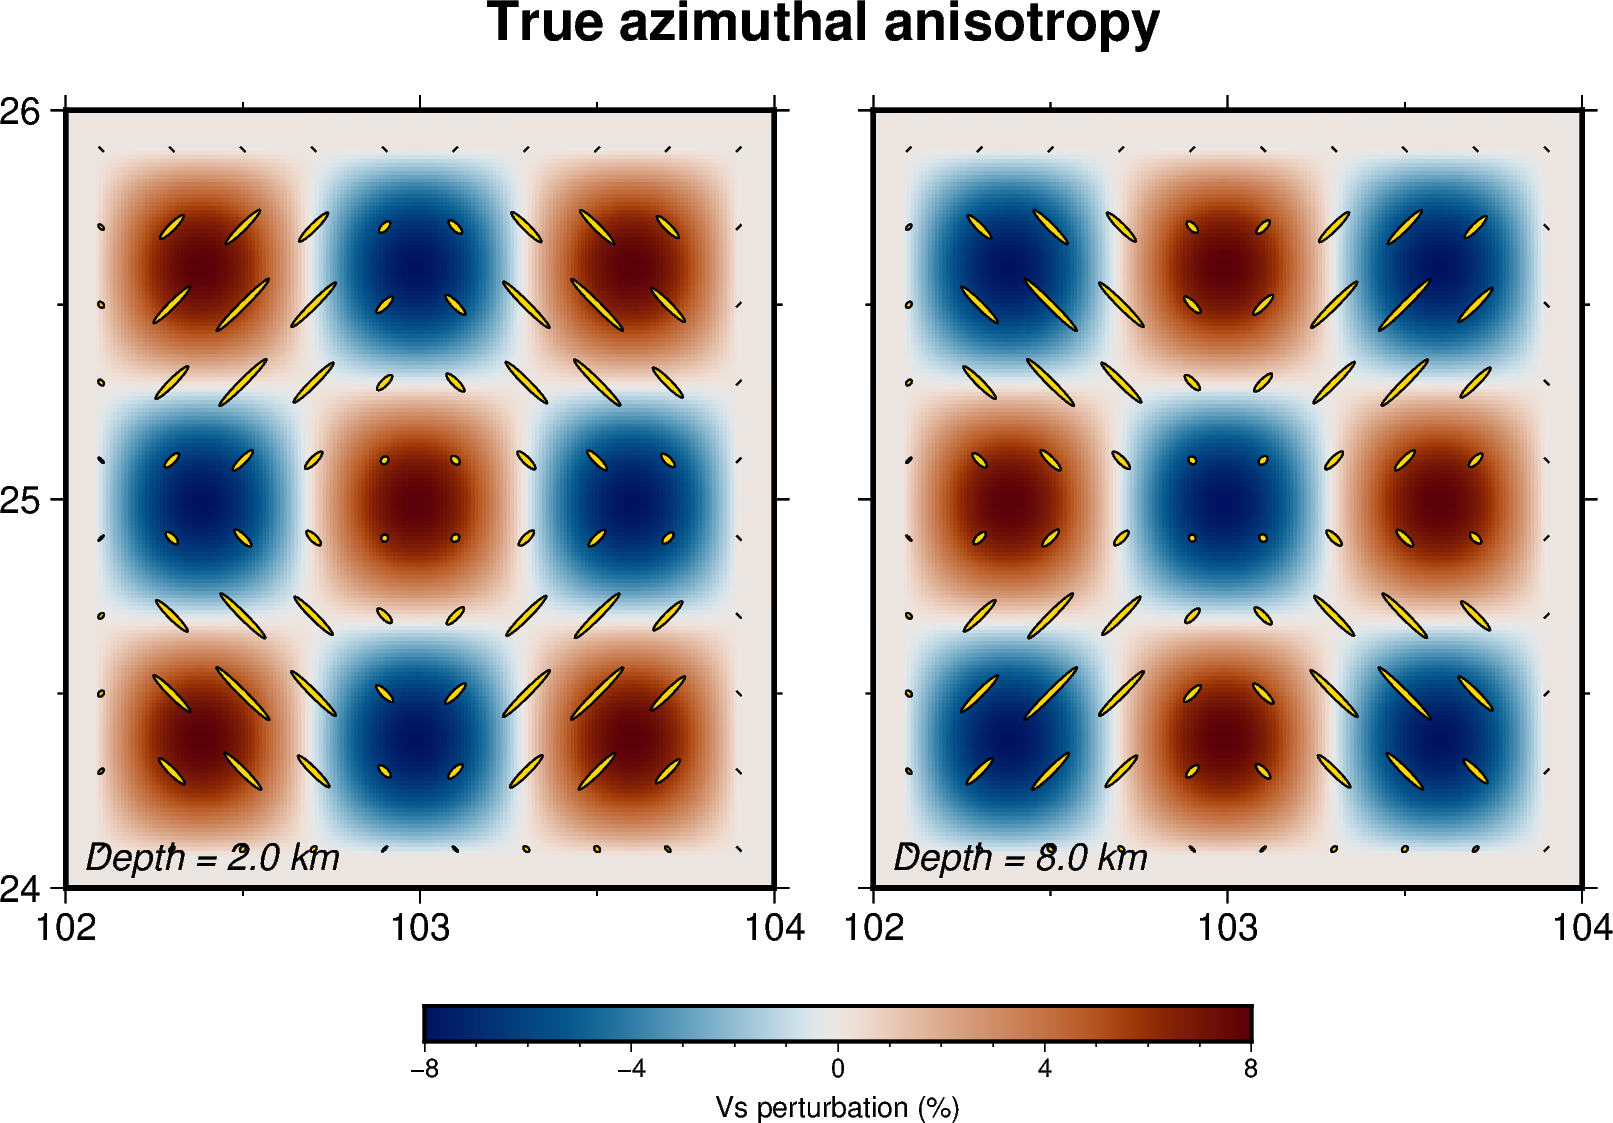

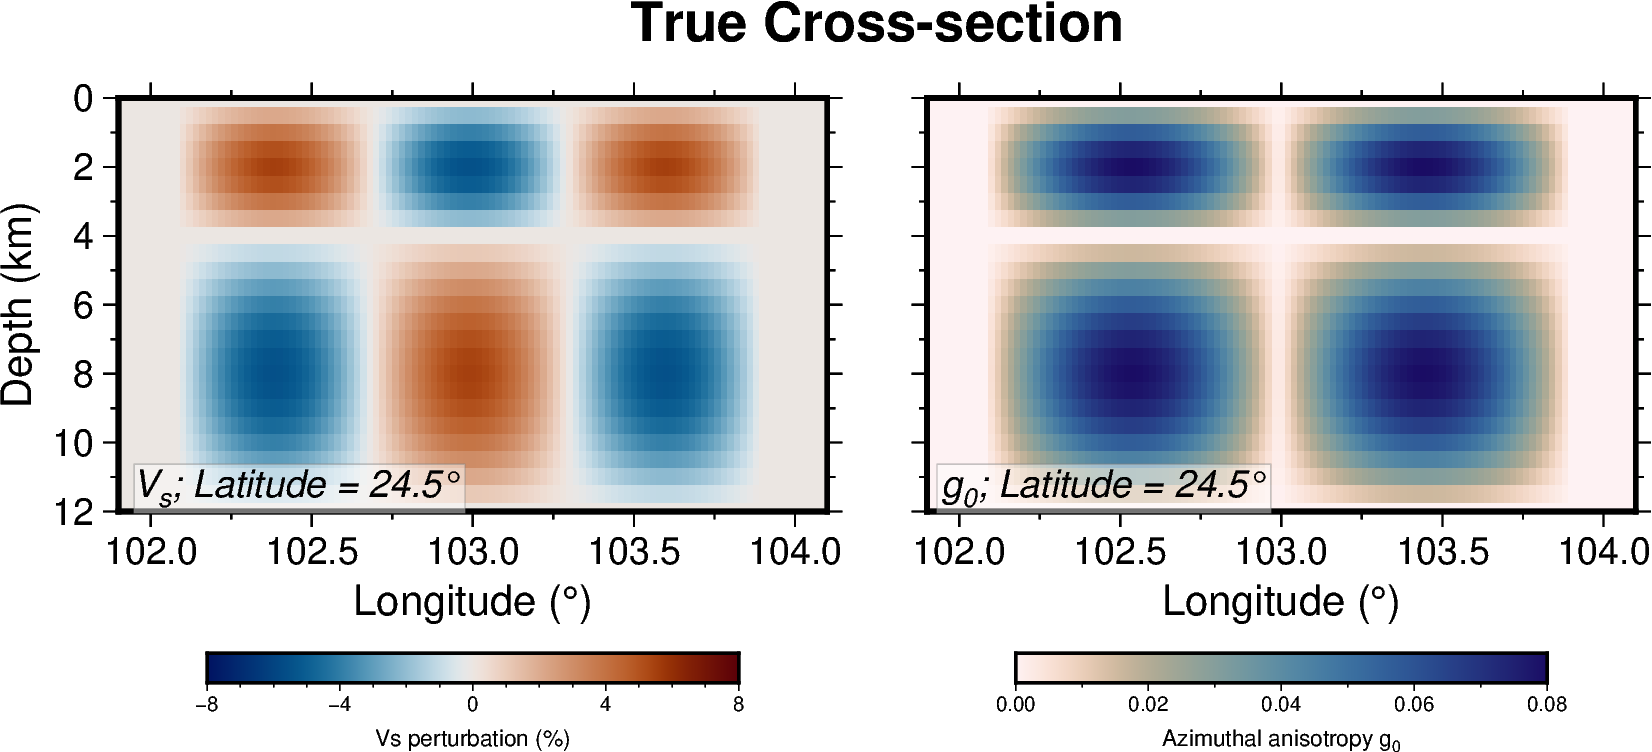

In [25]:
# Plot the true model
true_horizontal = plot_azimuthal_slices(
    dvt,
    target_gc,
    target_gs,
    "True",
    x,
    y,
    z,
)
true_vertical = plot_vertical_slice(
    dvt,
    target_gc,
    target_gs,
    "True",
    x,
    y,
    z,
    latitude=24.54,
)
true_horizontal.show()
true_vertical.show()

8.613813051003714e-05 0.06508363513351453


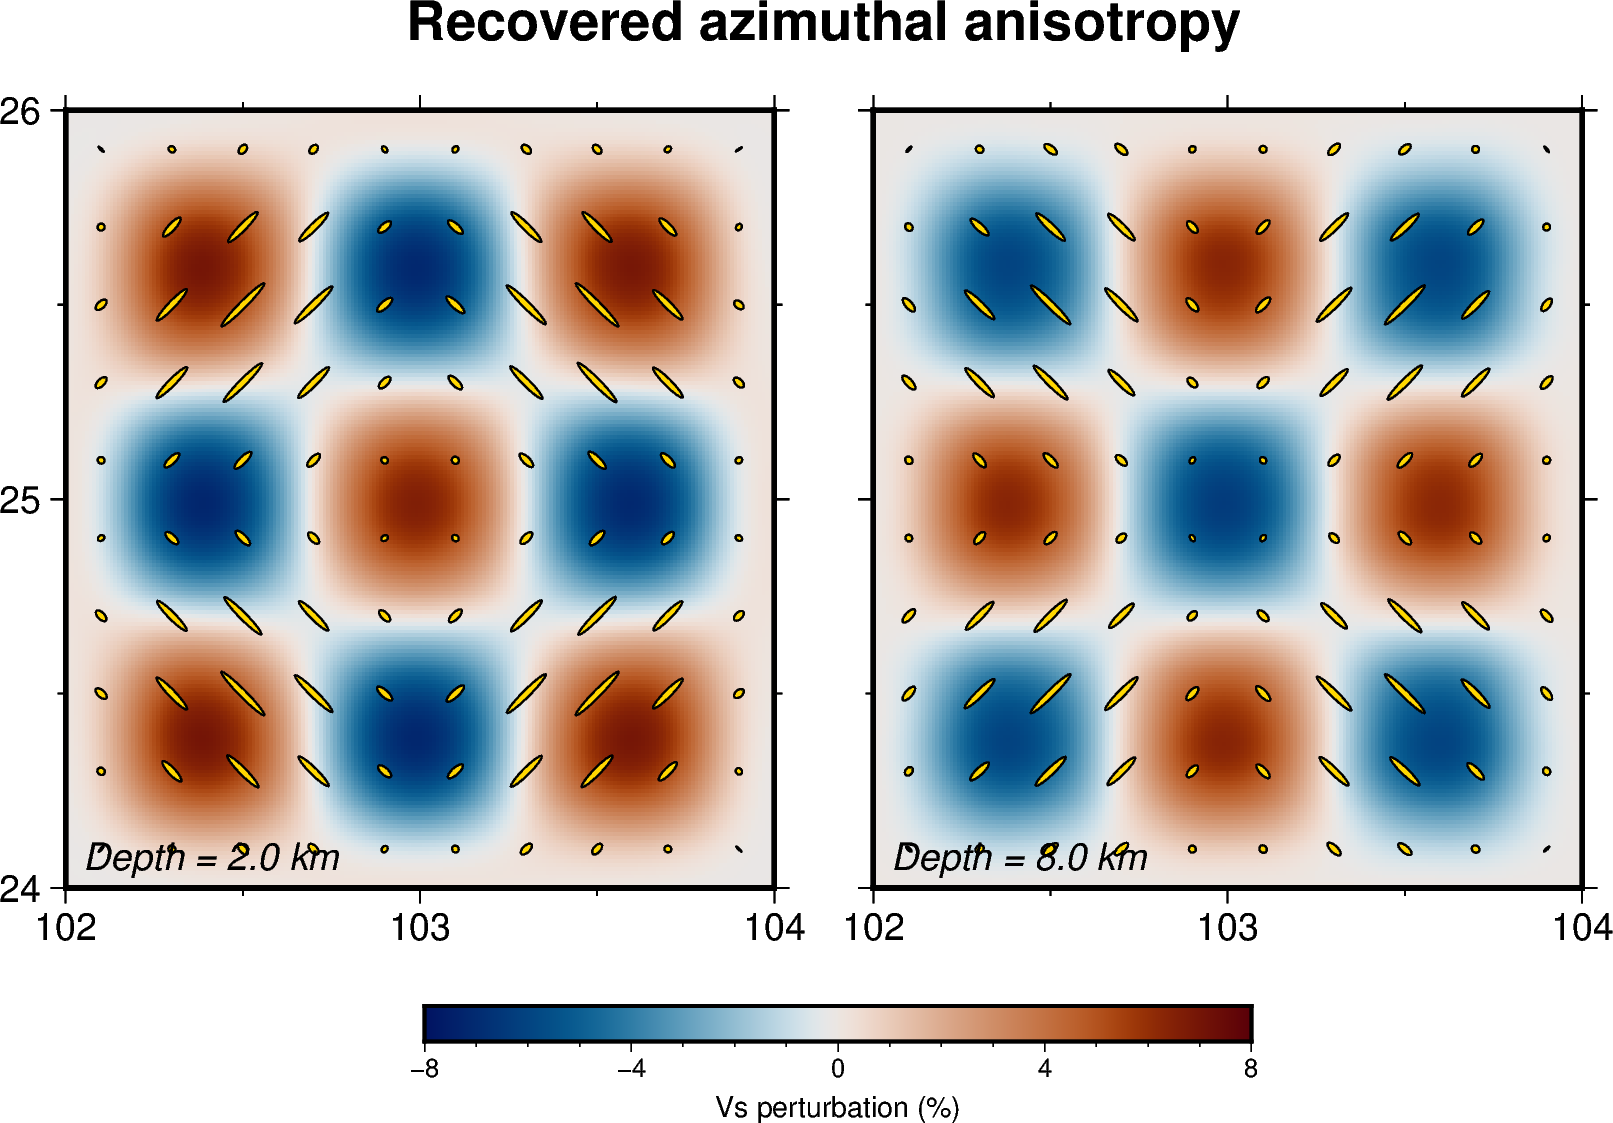

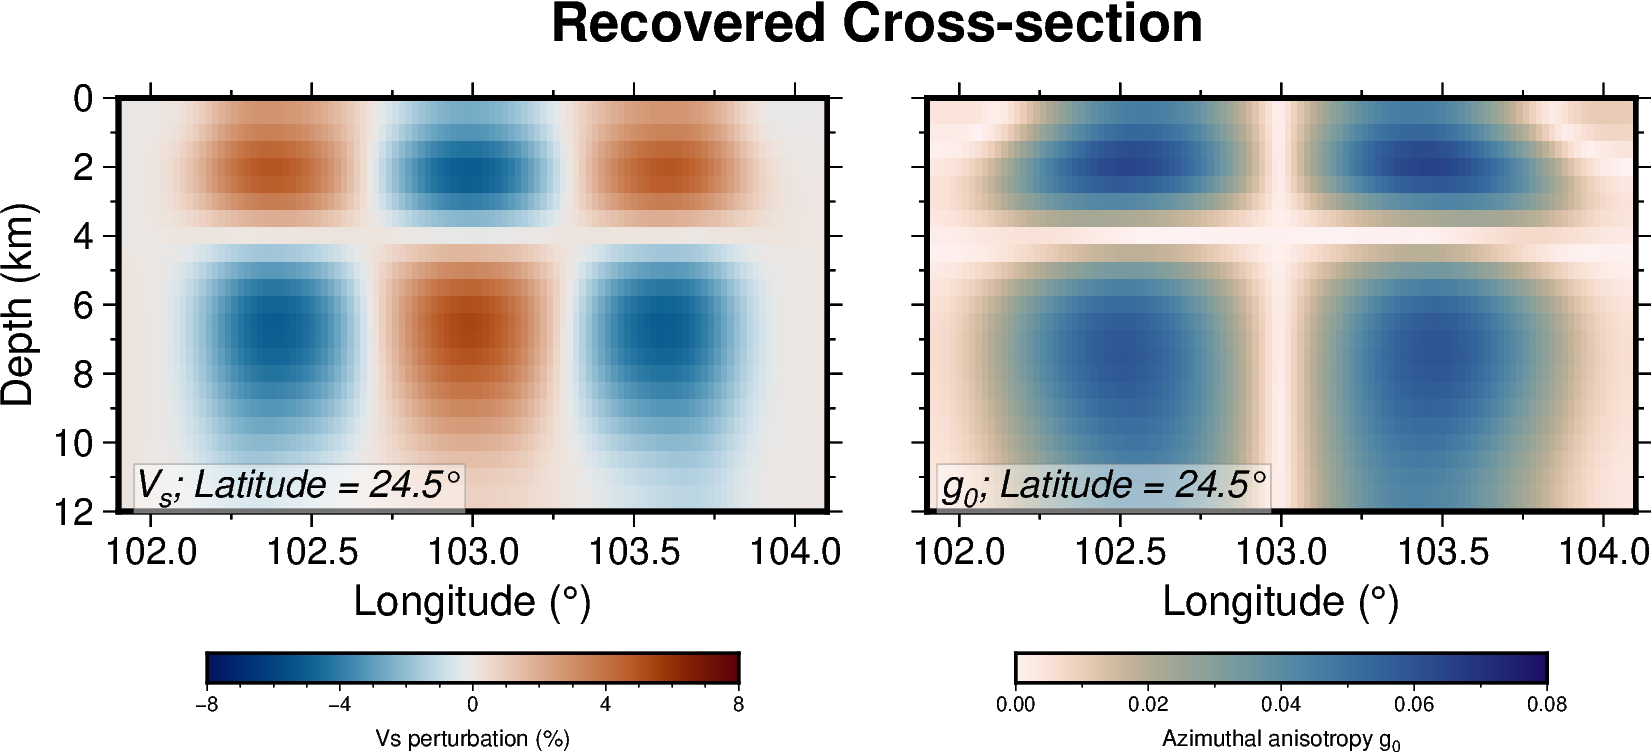

In [26]:
# Plot the inversion result with the same plotting function
result_horizontal = plot_azimuthal_slices(
    dv,
    final_gc,
    final_gs,
    "Recovered",
    x,
    y,
    z,
)
result_vertical = plot_vertical_slice(
    dv,
    final_gc,
    final_gs,
    "Recovered",
    x,
    y,
    z,
    latitude=24.54,
)
result_horizontal.show()
result_vertical.show()